<a href="https://colab.research.google.com/github/pavimunirajn2005-dev/Banking-FAQ-Assistant-final/blob/main/Banking_FAQ_Assistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BANKING FAQ ASSISTANCE
AI-powered Banking Frequently Asked Questions Assistant

**Architecture:** User Query → Text Preprocessing → TF-IDF → Similarity Matching → Confidence Check → FAQ Answer / Safe Fallback

This prototype uses a controlled static FAQ knowledge base. No Gemini/OpenAI API key is required.


In [ ]:
# STEP 1 — Install and import libraries
!pip -q install scikit-learn pandas matplotlib

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Banking FAQ Assistant is ready.")


Banking FAQ Assistant is ready.


## STEP 2 — Static Banking FAQ Context
The following approved-style sample FAQs form the system's knowledge base. For real deployment, replace them with official bank-approved content.


In [ ]:
faq_data = [
("account_opening","Account","How can I open a bank account?","Follow the bank's official account-opening process and provide the required documents."),
("account_balance","Account","How can I check my account balance?","Check your balance through the bank's official mobile app, internet banking, ATM, or branch."),
("account_statement","Account","How can I get my bank statement?","Download or request your statement through official internet banking, the mobile app, or a bank branch."),
("atm_lost","ATM / Debit Card","What should I do if my ATM card is lost?","Block the lost card immediately using an official banking channel or contact bank support."),
("atm_pin","ATM / Debit Card","How can I change my ATM PIN?","Use the bank's authorized ATM or official banking channel that provides the PIN-change facility."),
("atm_cash","ATM / Debit Card","What if the ATM did not give me cash but my account was debited?","Keep the transaction details and report the failed cash withdrawal through official bank support."),
("upi_setup","UPI","How do I set up UPI?","Use an official UPI-enabled banking application, register your mobile number and bank account, and follow verification."),
("upi_failed","UPI","Why did my UPI payment fail?","A UPI payment can fail due to connectivity, bank-server, limit, account, or beneficiary issues. Check official transaction status."),
("upi_wrong","UPI","What if I sent money to the wrong UPI ID?","Report the transaction immediately through your bank or UPI application with the transaction reference details."),
("netbanking","Net Banking","How can I activate internet banking?","Use the bank's official website or mobile application and follow its registration or activation procedure."),
("password","Net Banking","I forgot my internet banking password. What should I do?","Use the official forgot-password or password-reset option. Never share your password or OTP."),
("loan_eligibility","Loans","How can I know whether I am eligible for a loan?","Eligibility depends on factors such as income, credit history, existing obligations, and the bank's current criteria."),
("loan_interest","Loans","What is loan interest?","Loan interest is the amount charged by a lender for providing funds. The rate depends on the loan product and terms."),
("credit_lost","Credit Card","What should I do if my credit card is lost?","Block the card immediately through an official banking channel and contact the card issuer."),
("credit_payment","Credit Card","How can I pay my credit card bill?","Pay through the card issuer's official app, internet banking, bank transfer, or another supported method."),
("pending","Transactions","Why is my bank transaction pending?","A transaction can remain pending while processing or confirmation is in progress. Check the official transaction status."),
("failed","Transactions","What should I do if my transaction failed?","Check the transaction status and account balance. If money was debited or the issue continues, contact official bank support."),
("charges","Charges","Why was a bank service charge deducted?","Banks may apply charges according to account or service terms. Check the official schedule of charges."),
("fraud","Security","What should I do if I notice an unauthorized transaction?","Report it immediately through the bank's official fraud-reporting or customer-support channel."),
("otp","Security","Should I share my OTP with anyone?","No. Never share an OTP, PIN, password, CVV, or authentication information with anyone."),
("support","General","How can I contact my bank?","Use the official phone number, website, mobile application, or branch information published by your bank.")
]

faq_df = pd.DataFrame(faq_data, columns=["intent","category","question","answer"])
print("FAQs:", len(faq_df))
faq_df


FAQs: 21


,intent,category,question,answer
0,account_opening,Account,How can I open a bank account?,Follow the bank's official account-opening pro...
1,account_balance,Account,How can I check my account balance?,Check your balance through the bank's official...
2,account_statement,Account,How can I get my bank statement?,Download or request your statement through off...
3,atm_lost,ATM / Debit Card,What should I do if my ATM card is lost?,Block the lost card immediately using an offic...
4,atm_pin,ATM / Debit Card,How can I change my ATM PIN?,Use the bank's authorized ATM or official bank...
5,atm_cash,ATM / Debit Card,What if the ATM did not give me cash but my ac...,Keep the transaction details and report the fa...
6,upi_setup,UPI,How do I set up UPI?,Use an official UPI-enabled banking applicatio...
7,upi_failed,UPI,Why did my UPI payment fail?,"A UPI payment can fail due to connectivity, ba..."
8,upi_wrong,UPI,What if I sent money to the wrong UPI ID?,Report the transaction immediately through you...
9,netbanking,Net Banking,How can I activate internet banking?,Use the bank's official website or mobile appl...


In [ ]:
# STEP 3 — Add alternative ways users may ask the same question
alternatives = {
"account_opening":["how do I create a bank account","I want to open an account"],
"account_balance":["tell me my balance","check bank balance"],
"account_statement":["download statement","need account statement"],
"atm_lost":["I lost my debit card","my ATM card is missing"],
"atm_pin":["change debit card PIN","reset ATM PIN"],
"atm_cash":["cash not received from ATM","ATM debited but no cash"],
"upi_setup":["how to use UPI","create UPI"],
"upi_failed":["UPI transaction failed","UPI payment not working"],
"upi_wrong":["sent money to wrong UPI","wrong UPI payment"],
"netbanking":["register internet banking","activate online banking"],
"password":["forgot net banking password","reset online banking password"],
"loan_eligibility":["am I eligible for a loan","loan eligibility criteria"],
"loan_interest":["interest on loan","how does loan interest work"],
"credit_lost":["lost credit card","credit card stolen"],
"credit_payment":["pay credit card bill","credit card bill payment"],
"pending":["payment pending","pending transfer"],
"failed":["transaction failed","payment failed"],
"charges":["why did bank charge me","service fee deducted"],
"fraud":["unknown transaction in my account","report fraud transaction"],
"otp":["can I tell someone my OTP","is it safe to share OTP"],
"support":["bank customer care","contact bank support"]
}

rows=[]
for _, r in faq_df.iterrows():
    rows.append(list(r))
    for q in alternatives.get(r.intent, []):
        rows.append([r.intent,r.category,q,r.answer])

train_df=pd.DataFrame(rows,columns=["intent","category","question","answer"])
print("Training examples:",len(train_df))


Training examples: 63


In [ ]:
# STEP 4 — Text preprocessing
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

train_df["clean_question"] = train_df["question"].apply(clean_text)
print("Preprocessing completed.")


Preprocessing completed.


In [ ]:
# STEP 5 — TF-IDF model
vectorizer = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)
faq_matrix = vectorizer.fit_transform(train_df["clean_question"])
print("TF-IDF matrix:", faq_matrix.shape)


TF-IDF matrix: (63, 276)


In [ ]:
# STEP 6 — Banking FAQ Assistant
CONFIDENCE_THRESHOLD = 0.20

def banking_faq_assistant(user_query, show_score=True):
    if not str(user_query).strip():
        return "Please enter a banking question."

    q = vectorizer.transform([clean_text(user_query)])
    scores = cosine_similarity(q, faq_matrix)[0]
    idx = int(np.argmax(scores))
    score = float(scores[idx])
    result = train_df.iloc[idx]

    if score < CONFIDENCE_THRESHOLD:
        answer = ("I could not find a reliable answer in the Banking FAQ knowledge base. "
                  "Please rephrase your question or contact the bank through its official support channel.")
    else:
        answer = (f"Category: {result['category']}\n"
                  f"Matched FAQ: {result['question']}\n"
                  f"Answer: {result['answer']}")

    if show_score:
        answer += f"\nConfidence score: {score:.3f}"
    return answer

print(banking_faq_assistant("I lost my ATM card"))


Category: ATM / Debit Card
Matched FAQ: my ATM card is missing
Answer: Block the lost card immediately using an official banking channel or contact bank support.
Confidence score: 0.528


## STEP 7 — Test the Assistant

In [ ]:
test_questions = [
"How do I check my bank balance?",
"My debit card is lost",
"Why did my UPI payment fail?",
"I forgot my online banking password",
"I see an unauthorized transaction",
"Can I share my OTP with a caller?",
"How can I pay my credit card bill?",
"What is loan interest?",
"Tell me about quantum physics"
]

for q in test_questions:
    print("="*75)
    print("USER:", q)
    print(banking_faq_assistant(q))


USER: How do I check my bank balance?
Category: Account
Matched FAQ: check bank balance
Answer: Check your balance through the bank's official mobile app, internet banking, ATM, or branch.
Confidence score: 0.578
USER: My debit card is lost
Category: ATM / Debit Card
Matched FAQ: I lost my debit card
Answer: Block the lost card immediately using an official banking channel or contact bank support.
Confidence score: 0.722
USER: Why did my UPI payment fail?
Category: UPI
Matched FAQ: Why did my UPI payment fail?
Answer: A UPI payment can fail due to connectivity, bank-server, limit, account, or beneficiary issues. Check official transaction status.
Confidence score: 1.000
USER: I forgot my online banking password
Category: Net Banking
Matched FAQ: reset online banking password
Answer: Use the official forgot-password or password-reset option. Never share your password or OTP.
Confidence score: 0.649
USER: I see an unauthorized transaction
Category: Security
Matched FAQ: What should I do 

## STEP 8 — FAQ Category Visualization

category
Account             3
ATM / Debit Card    3
UPI                 3
Net Banking         2
Loans               2
Credit Card         2
Transactions        2
Security            2
Charges             1
General             1
Name: count, dtype: int64


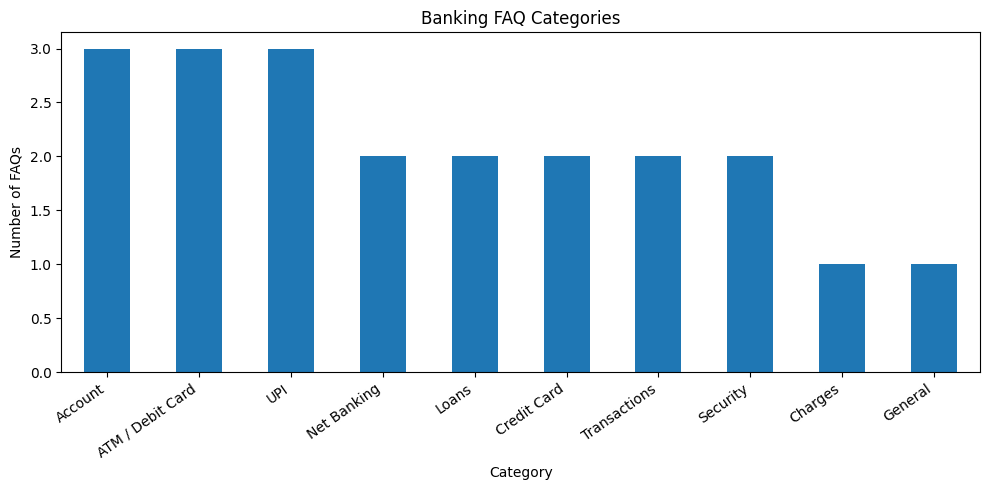

In [ ]:
counts = faq_df["category"].value_counts()
print(counts)

plt.figure(figsize=(10,5))
counts.plot(kind="bar")
plt.title("Banking FAQ Categories")
plt.xlabel("Category")
plt.ylabel("Number of FAQs")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## STEP 9 — Interactive Banking FAQ Chat
Run the next cell and type your banking questions. Type `exit` to stop.


In [ ]:
# ============================================================
# BANKING FAQ ASSISTANT - USER INPUT
# ============================================================

print("=" * 60)
print("              BANKING FAQ ASSISTANT")
print("=" * 60)
print("Type your banking question below.")
print("Type 'exit' to stop.")
print("=" * 60)

while True:

    question = input("\nEnter your banking question: ")

    if question.lower().strip() == "exit":
        print("\nThank you for using Banking FAQ Assistant.")
        break

    if question.strip() == "":
        print("Please enter a question.")
        continue

    print("\n" + "-" * 60)
    print("USER:", question)
    print("-" * 60)

    result = banking_faq_assistant(question)

    print("ASSISTANT:")
    print(result)

              BANKING FAQ ASSISTANT
Type your banking question below.
Type 'exit' to stop.

------------------------------------------------------------
USER: i should cretae a bank account
------------------------------------------------------------
ASSISTANT:
Category: Account
Matched FAQ: How can I open a bank account?
Answer: Follow the bank's official account-opening process and provide the required documents.
Confidence score: 0.476

------------------------------------------------------------
USER: How do I set up UPI
------------------------------------------------------------
ASSISTANT:
Category: UPI
Matched FAQ: How do I set up UPI?
Answer: Use an official UPI-enabled banking application, register your mobile number and bank account, and follow verification.
Confidence score: 1.000


## STEP 10 — System Architecture

```text
                 BANKING FAQ ASSISTANCE
                           |
                           v
                  +------------------+
                  |   User Query     |
                  +--------+---------+
                           |
                           v
                  +------------------+
                  | Text Processing  |
                  +--------+---------+
                           |
                           v
                  +------------------+
                  |  TF-IDF Model    |
                  +--------+---------+
                           |
                           v
                  +------------------+
                  | Similarity Match |
                  +--------+---------+
                           |
                           v
               +-----------------------+
               | Static Banking FAQ    |
               | Knowledge Base        |
               +-----------+-----------+
                           |
                           v
                  +------------------+
                  | Confidence Check |
                  +--------+---------+
                           |
                    +------+------+
                    |             |
                 Reliable      No Match
                    |             |
                    v             v
              +-----------+  +-------------+
              | FAQ Answer|  | Safe        |
              | Retrieved |  | Fallback    |
              +-----+-----+  +-------------+
                    |
                    v
              +-----------+
              |  Response |
              |  to User  |
              +-----------+
```


## STEP 11 — Project Explanation

1. **User Query:** Customer enters a banking question.
2. **Text Processing:** The question is cleaned.
3. **TF-IDF:** The question becomes a numerical vector.
4. **Similarity Matching:** Cosine similarity compares it with stored FAQ questions.
5. **FAQ Retrieval:** The closest FAQ is selected.
6. **Confidence Check:** Low-confidence questions are not guessed.
7. **Response:** The approved FAQ answer or safe fallback is displayed.

### Security
Never request or store passwords, PINs, OTPs, CVV numbers, full card numbers, or other sensitive credentials. This prototype provides general FAQ guidance and does not perform banking transactions.
